# Geometric Corrections: systematic errors

$\varepsilon_{\rm tot}$ (see `GeometricCorrections.ipynb`) comes from a Geant4/nexus simulation, so it depends on the
optical model assumed for the cell: how reflective the PTFE and the steel are, how the PTFE surface is modelled, etc.
These are not known exactly. To estimate how much this matters, the simulation was repeated for each gas and pressure
changing **one optical parameter at a time** (`data/MarcFactors/Error_all_pressures_*`).
This notebook recomputes $\varepsilon_{\rm tot}$ for each variation, in exactly the same way as
`GeometricCorrections.ipynb`, and turns the change into a relative systematic shift on the LCE.

## The variations

Each folder `Error_all_pressures_<gas>/<gas>_<p>bar_error_correct` (1.5 to 8.5 bar) has one file per variation, with
20000 alphas and the same photon summary as the nominal files. The optical parameters themselves are not stored in the
files (`MC/configuration` only differs in the gas and the output name), so they are read from the file names:

| file tag | group | meaning |
|---|---|---|
| `PTFE95` | nominal | identical (event by event) to the nominal files in `*_correct`: the nominal PTFE reflectivity is 95% |
| `PTFE60`, `PTFE85`, `PTFE99` | PTFE reflectivity | PTFE reflectivity 60%, 85%, 99% |
| `PTFE01`, `PTFE05` (Ar only) | PTFE reflectivity | same naming as above, so taken as 1% and 5%. **To check with whoever made the simulation**: they could also be polishing values (like `PTFE_polish05` in Xe) |
| `PTFE_polished`, `PTFE_polish05` (Xe only) | PTFE polishing | PTFE surface fully polished / polishing 0.5 instead of the nominal rough surface |
| `PTFE_unified` | UNIFIED model | PTFE surface described with the Geant4 UNIFIED optical model |
| `STEEL0501` | Steel reflectivity | different steel reflectivity (the source holder and the metal parts) |
| `base20k` | MC statistics | a second simulation with the nominal settings: its difference to the nominal is just statistical noise |

The grouping is set in `SYST_GROUPS` below and can be changed there.

In [24]:
import glob
import os
import re

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

In [25]:
font_size = 20
# Configure matplotlib to use Computer Modern fonts and mathtext
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = font_size

GAS_NAMES  = {'Ar': 'Argon', 'Xe': 'Xenon'}
GAS_COLORS = {'Xe': 'darkred', 'Ar': 'darkgreen'}

In [26]:
data_dir = '/home/marian/CIGAR_ANALYSIS/CIGAR/data/MarcFactors'

# Nominal files: (gas, pressure) -> path
nominal_files = {}
for path in glob.glob(os.path.join(data_dir, '*_correct', 'Cigar_*_alpha_*.next.h5')):
    m = re.search(r'Cigar_([\d.]+)_alpha_(Ar|Xe)\.next\.h5', os.path.basename(path))
    nominal_files[(m.group(2), float(m.group(1)))] = path

# Variations: (gas, pressure, tag) -> path
variation_files = {}
for path in glob.glob(os.path.join(data_dir, 'Error_all_pressures_*', '*_error_correct', 'Cigar_*_alpha_*_*.next.h5')):
    m = re.search(r'Cigar_([\d.]+)_alpha_(Ar|Xe)_(\w+)\.next\.h5', os.path.basename(path))
    variation_files[(m.group(2), float(m.group(1)), m.group(3))] = path

for gas in ('Ar', 'Xe'):
    pressures = sorted({p for g, p, _ in variation_files if g == gas})
    tags      = sorted({t for g, _, t in variation_files if g == gas})
    print(f"{gas}: {pressures} bar\n    {tags}")

Ar: [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5] bar
    ['PTFE01', 'PTFE05', 'PTFE60', 'PTFE85', 'PTFE95', 'PTFE99', 'PTFE_polished', 'PTFE_unified', 'STEEL0501', 'base20k']
Xe: [1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5] bar
    ['PTFE60', 'PTFE85', 'PTFE95', 'PTFE99', 'PTFE_polish05', 'PTFE_polished', 'PTFE_unified', 'STEEL0501', 'base20k']


## Settings

* `pressure`: pressure of the systematics plot (8.5 bar as in the reference figure).
* `photon_threshold`: same full-energy selection as in `GeometricCorrections.ipynb`.
* `SYST_GROUPS`: which variations make up each systematic. A group that does not exist for a gas (e.g. `PTFE_polish05` in Ar) is just skipped.
* `STAT_GROUP`: the statistical replica, shown for reference but **not** added to the total.
* `method`: how $\varepsilon_{\rm tot}$ is computed from each file (see next section).

In [27]:
pressure         = 8.5    # [bar]
photon_threshold = 80
n_bins_photons   = 50
method           = 'mean'   # 'mean' (recommended here) or 'fit' (2D Gaussian, as in GeometricCorrections.ipynb)

SYST_GROUPS = {
    'Steel reflectivity': ['STEEL0501'],
    'UNIFIED model'     : ['PTFE_unified'],
    'PTFE reflectivity' : ['PTFE60', 'PTFE85', 'PTFE99', 'PTFE01', 'PTFE05'],
    'PTFE polishing'    : ['PTFE_polished', 'PTFE_polish05'],
}
STAT_GROUP = {'MC statistics': ['base20k']}

## $\varepsilon_{\rm tot}$ of each simulation

As in `GeometricCorrections.ipynb` (see that notebook for the physics), only the full-energy alphas
(`photons_created >= photon_threshold`) are used and

$$\varepsilon_{\rm tot} = 1 - \frac{\mu_{\rm teflon}}{\mu_{\rm photons}} - \frac{\mu_{\rm source}}{\mu_{\rm photons}}$$

The means $\mu$ can be obtained in two ways (`method`):

* `'mean'`: $\mu_{\rm hits}/\mu_{\rm photons} = \sum {\rm hits} / \sum {\rm photons}$ over the selected events. Error from the
  event-by-event scatter around that ratio.
* `'fit'`: the means of the 2D Gaussian fit, exactly as in `GeometricCorrections.ipynb`.

**Why `'mean'` here.** A systematic shift is a *difference* between two simulations, often well below 1%, so what
matters is that the estimator does not add noise of its own. The `base20k` replica (same settings as the nominal,
other random numbers) shows that the fit does: at 8.5 bar the fit gives nominal and replica 0.0037 (Xe) and 0.0048 (Ar)
apart, 2.5–3.5 times their quoted errors, while the plain ratio of sums gives 0.0011 and 0.0003, compatible with the
statistics. The fit reacts to small changes in the shape of the peak and in how the events fall in the bins, which is
not what we want to measure here. The two methods give $\varepsilon_{\rm tot}$ values within ~1% of each other,
so the relative shifts are the same up to that noise.

In [28]:
def gaussian_2d(xy, A, mux, muy, sx, sy, rho):
    x, y = xy
    dx, dy = (x - mux) / sx, (y - muy) / sy
    z = (dx**2 - 2 * rho * dx * dy + dy**2) / (1 - rho**2)
    return A * np.exp(-0.5 * z)


def hist_edges(x, y, n_bins_photons=50):
    x_edges = np.linspace(0, x.max() + 1, n_bins_photons + 1)
    y_edges = np.arange(-0.5, y.max() + 1.5, max(1, int(np.ceil((y.max() + 1) / 80))))
    return x_edges, y_edges


def fit_gaussian_2d(x, y, x_edges, y_edges, threshold):
    '''Fit a correlated 2D Gaussian to the histogram of the events with x >= threshold.'''
    sel = x >= threshold
    H, _, _ = np.histogram2d(x[sel], y[sel], bins=[x_edges, y_edges])

    xc = 0.5 * (x_edges[1:] + x_edges[:-1])
    yc = 0.5 * (y_edges[1:] + y_edges[:-1])
    X, Y = np.meshgrid(xc, yc, indexing='ij')

    p0 = [H.max(), x[sel].mean(), y[sel].mean(), x[sel].std(), y[sel].std(),
          np.corrcoef(x[sel], y[sel])[0, 1]]

    mask = (X >= threshold).ravel()
    sigma = np.sqrt(np.maximum(H.ravel()[mask], 1))
    popt, pcov = curve_fit(gaussian_2d, (X.ravel()[mask], Y.ravel()[mask]), H.ravel()[mask],
                           p0=p0, sigma=sigma, absolute_sigma=True,
                           bounds=([0, -np.inf, -np.inf, 1e-3, 1e-3, -0.99],
                                   [np.inf, np.inf, np.inf, np.inf, np.inf, 0.99]))
    return popt, pcov


def absorbed_fraction(popt, pcov):
    '''mu_hits / mu_photons with its error (including the mu_x - mu_y covariance).'''
    mux, muy = popt[1], popt[2]
    f = muy / mux
    f_err = abs(f) * np.sqrt(pcov[2, 2] / muy**2 + pcov[1, 1] / mux**2 - 2 * pcov[1, 2] / (mux * muy))
    return f, f_err


def mean_fraction(x, y, threshold):
    '''sum(hits) / sum(photons) of the events with x >= threshold, with its error.'''
    sel = x >= threshold
    x, y = x[sel].astype(float), y[sel].astype(float)
    f = y.sum() / x.sum()
    return f, np.sqrt(np.sum((y - f * x)**2)) / x.sum()


def eps_tot_of_file(path, threshold, method='mean'):
    with h5py.File(path, 'r') as f:
        df = pd.DataFrame(f['MC/photon_summary'][:])
    x = df['photons_created'].to_numpy()
    fractions = []
    for column in ('source_hits', 'teflon_hits'):
        y = df[column].to_numpy()
        if method == 'fit':
            x_edges, y_edges = hist_edges(x, y, n_bins_photons)
            fractions.append(absorbed_fraction(*fit_gaussian_2d(x, y, x_edges, y_edges, threshold)))
        else:
            fractions.append(mean_fraction(x, y, threshold))
    (f_s, f_s_err), (f_t, f_t_err) = fractions
    return 1 - f_s - f_t, np.hypot(f_s_err, f_t_err)

In [29]:
def eps_table(pressure, threshold, method='mean'):
    '''eps_tot of the nominal and of every variation, for both gases, at one pressure.'''
    rows = []
    for gas in ('Xe', 'Ar'):
        eps, err = eps_tot_of_file(nominal_files[(gas, pressure)], threshold, method)
        rows.append({'gas': gas, 'tag': 'nominal', 'eps_tot': eps, 'eps_tot_err': err})
        for (g, p, tag), path in sorted(variation_files.items()):
            if g == gas and p == pressure:
                eps, err = eps_tot_of_file(path, threshold, method)
                rows.append({'gas': gas, 'tag': tag, 'eps_tot': eps, 'eps_tot_err': err})
    return pd.DataFrame(rows)


eps_df = eps_table(pressure, photon_threshold, method)
eps_df.pivot(index='tag', columns='gas', values='eps_tot').round(4)

gas,Ar,Xe
tag,,
PTFE01,0.4772,NaN
PTFE05,0.4772,NaN
PTFE60,0.4773,0.4598
PTFE85,0.4772,0.4597
PTFE95,0.4771,0.4576
PTFE99,0.4776,0.4595
PTFE_polish05,NaN,0.4591
PTFE_polished,0.4777,0.4608
PTFE_unified,0.4765,0.4606


## Systematic shift on the LCE

The LCE is computed as (`EfficiencyVSPressure.ipynb`)

$$\mathrm{LCE} = \frac{N_{\rm p.e.} - N_{\rm DCR}}{N_\gamma \cdot \varepsilon_{\rm tot}}$$

so if the optical model were the one of a variation instead of the nominal one, the LCE would change by

$$\frac{\Delta \mathrm{LCE}}{\mathrm{LCE}} = \frac{\varepsilon_{\rm tot}^{\rm nominal}}{\varepsilon_{\rm tot}^{\rm variation}} - 1$$

A variation where more photons survive (larger $\varepsilon_{\rm tot}$) means more photons were available to
be detected, so the LCE goes **down**, and the other way round.

**Per group.** A group can have several variations (e.g. three PTFE reflectivities). Its bar goes from the most negative
to the most positive shift of its variations (including 0, the nominal itself). This is a conservative envelope, not a
standard deviation.

**Total.** The groups are independent, so their shifts are added in quadrature, separately for each side:

$$\delta_{\rm total}^{\pm} = \sqrt{\sum_{\rm groups} \left(\delta_{\rm group}^{\pm}\right)^2}$$

**MC statistics.** The `base20k` replica is the same simulation as the nominal one with other random numbers, so its shift
is the size of the purely statistical fluctuations. A group whose bar is about that size is compatible with **no effect**.
It is drawn for reference and is not added to the total.

In [30]:
def lce_shift(eps_nominal, eps_variation):
    '''Relative change of the LCE [%] if eps_variation is used instead of eps_nominal.'''
    return 100 * (eps_nominal / eps_variation - 1)


def systematic_shifts(eps_df, groups):
    '''{gas: {group: (shift_down, shift_up)}} [%], with shift_down <= 0 <= shift_up.'''
    shifts = {}
    for gas, d in eps_df.groupby('gas'):
        eps = dict(zip(d['tag'], d['eps_tot']))
        shifts[gas] = {}
        for group, tags in groups.items():
            s = [lce_shift(eps['nominal'], eps[t]) for t in tags if t in eps]
            if s:
                shifts[gas][group] = (min(0, *s), max(0, *s))
    return shifts


def total_shift(group_shifts):
    down = -np.sqrt(sum(lo**2 for lo, _ in group_shifts.values()))
    up   =  np.sqrt(sum(hi**2 for _, hi in group_shifts.values()))
    return down, up


syst  = systematic_shifts(eps_df, SYST_GROUPS)
stat  = systematic_shifts(eps_df, STAT_GROUP)
total = {gas: total_shift(s) for gas, s in syst.items()}

for gas in ('Xe', 'Ar'):
    print(f"{GAS_NAMES[gas]}, {pressure} bar:")
    for group, (lo, hi) in {**syst[gas], **stat[gas]}.items():
        print(f"  {group:>20s}: {lo:+6.2f}% / {hi:+6.2f}%")
    print(f"  {'Total':>20s}: {total[gas][0]:+6.2f}% / {total[gas][1]:+6.2f}%")

Xenon, 8.5 bar:
    Steel reflectivity:  -7.37% /  +0.00%
         UNIFIED model:  -0.64% /  +0.00%
     PTFE reflectivity:  -0.47% /  +0.00%
        PTFE polishing:  -0.69% /  +0.00%
         MC statistics:  -0.23% /  +0.00%
                 Total:  -7.45% /  +0.00%
Argon, 8.5 bar:
    Steel reflectivity:  -5.45% /  +0.00%
         UNIFIED model:  +0.00% /  +0.14%
     PTFE reflectivity:  -0.10% /  +0.00%
        PTFE polishing:  -0.12% /  +0.00%
         MC statistics:  +0.00% /  +0.06%
                 Total:  -5.45% /  +0.14%


## Systematics plot

One row per group (as in the reference figure), with xenon (dark red) above argon (dark green). The bar of each row goes from its negative
to its positive shift. Below the dashed line, the total (groups in quadrature) and, in grey, the MC statistics for reference.

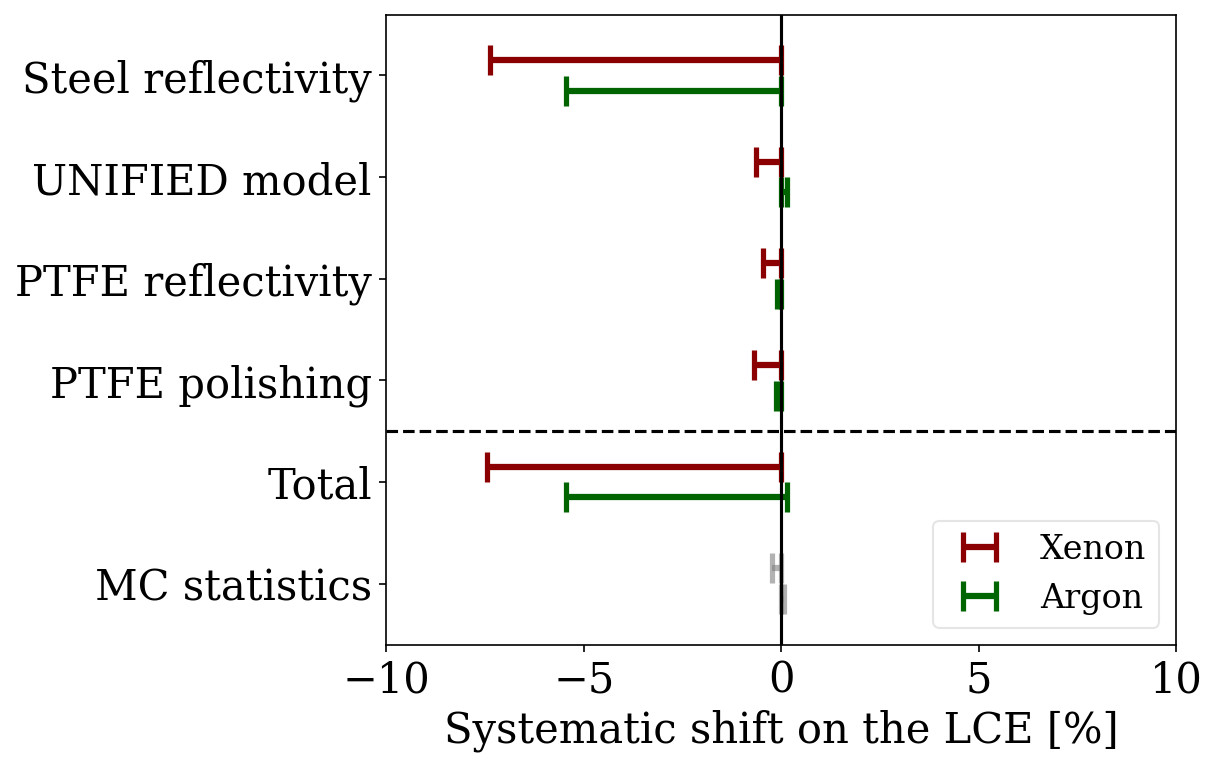

In [31]:
def plot_systematics(syst, total, stat, pressure, xlim=10):
    rows = list(SYST_GROUPS) + ['Total'] + list(STAT_GROUP)
    y = {row: len(rows) - 1 - k for k, row in enumerate(rows)}
    offset = {'Xe': 0.15, 'Ar': -0.15}

    fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=150, constrained_layout=True)

    for gas in ('Xe', 'Ar'):
        bars = {**syst[gas], 'Total': total[gas], **stat[gas]}
        for k, (row, (lo, hi)) in enumerate(bars.items()):
            color = 'grey' if row in STAT_GROUP else GAS_COLORS[gas]
            ax.errorbar(0, y[row] + offset[gas], xerr=[[-lo], [hi]], fmt='none', ecolor=color,
                        elinewidth=3, capsize=7, capthick=2.5, alpha=0.6 if row in STAT_GROUP else 1,
                        label=GAS_NAMES[gas] if k == 0 else None)

    ax.axvline(0, color='k', lw=1.5)
    ax.axhline(y['Total'] + 0.5, color='k', ls='--', lw=1.5)

    ax.set_yticks([y[r] for r in rows], rows)
    ax.set_ylim(-0.6, len(rows) - 0.4)
    ax.set_xlim(-xlim, xlim)
    ax.set_xlabel(r'Systematic shift on the LCE [%]')
    # ax.set_title(f'{pressure} bar')
    ax.legend(loc='lower right', framealpha=0.5, fontsize=0.8*font_size)
    plt.show()


plot_systematics(syst, total, stat, pressure)

## Total systematic vs pressure

The same calculation for every pressure with variations (1.5 to 8.5 bar). It reads and fits all the files
(~20 per pressure), so it takes a while. The result can be used as the systematic error band of the LCE in
`EfficiencyVSPressure.ipynb`.

In [32]:
all_pressures = sorted({p for _, p, _ in variation_files})

syst_vs_p = []
for p in all_pressures:
    d = eps_table(p, photon_threshold, method)
    s, st = systematic_shifts(d, SYST_GROUPS), systematic_shifts(d, STAT_GROUP)
    for gas in ('Xe', 'Ar'):
        lo, hi = total_shift(s[gas])
        row = {'gas': gas, 'pressure': p, 'total_down': lo, 'total_up': hi,
               'stat_down': st[gas]['MC statistics'][0], 'stat_up': st[gas]['MC statistics'][1]}
        row.update({f'{g}_down': v[0] for g, v in s[gas].items()})
        row.update({f'{g}_up': v[1] for g, v in s[gas].items()})
        syst_vs_p.append(row)

syst_vs_p = pd.DataFrame(syst_vs_p).set_index(['gas', 'pressure'])
syst_vs_p[['total_down', 'total_up', 'stat_down', 'stat_up']].round(2)

,,total_down,total_up,stat_down,stat_up
gas,pressure,,,,
Xe,1.5,-2.16,0.02,-0.08,0.00
Ar,1.5,-1.07,0.72,0.00,0.14
Xe,2.5,-3.40,0.40,0.00,0.06
Ar,2.5,-1.64,0.47,-0.01,0.00
Xe,3.5,-4.52,0.18,0.00,0.02
Ar,3.5,-2.72,0.00,-0.20,0.00
Xe,4.5,-5.86,0.06,-0.28,0.00
Ar,4.5,-3.52,0.05,-0.07,0.00
Xe,5.5,-6.30,0.12,0.00,0.01


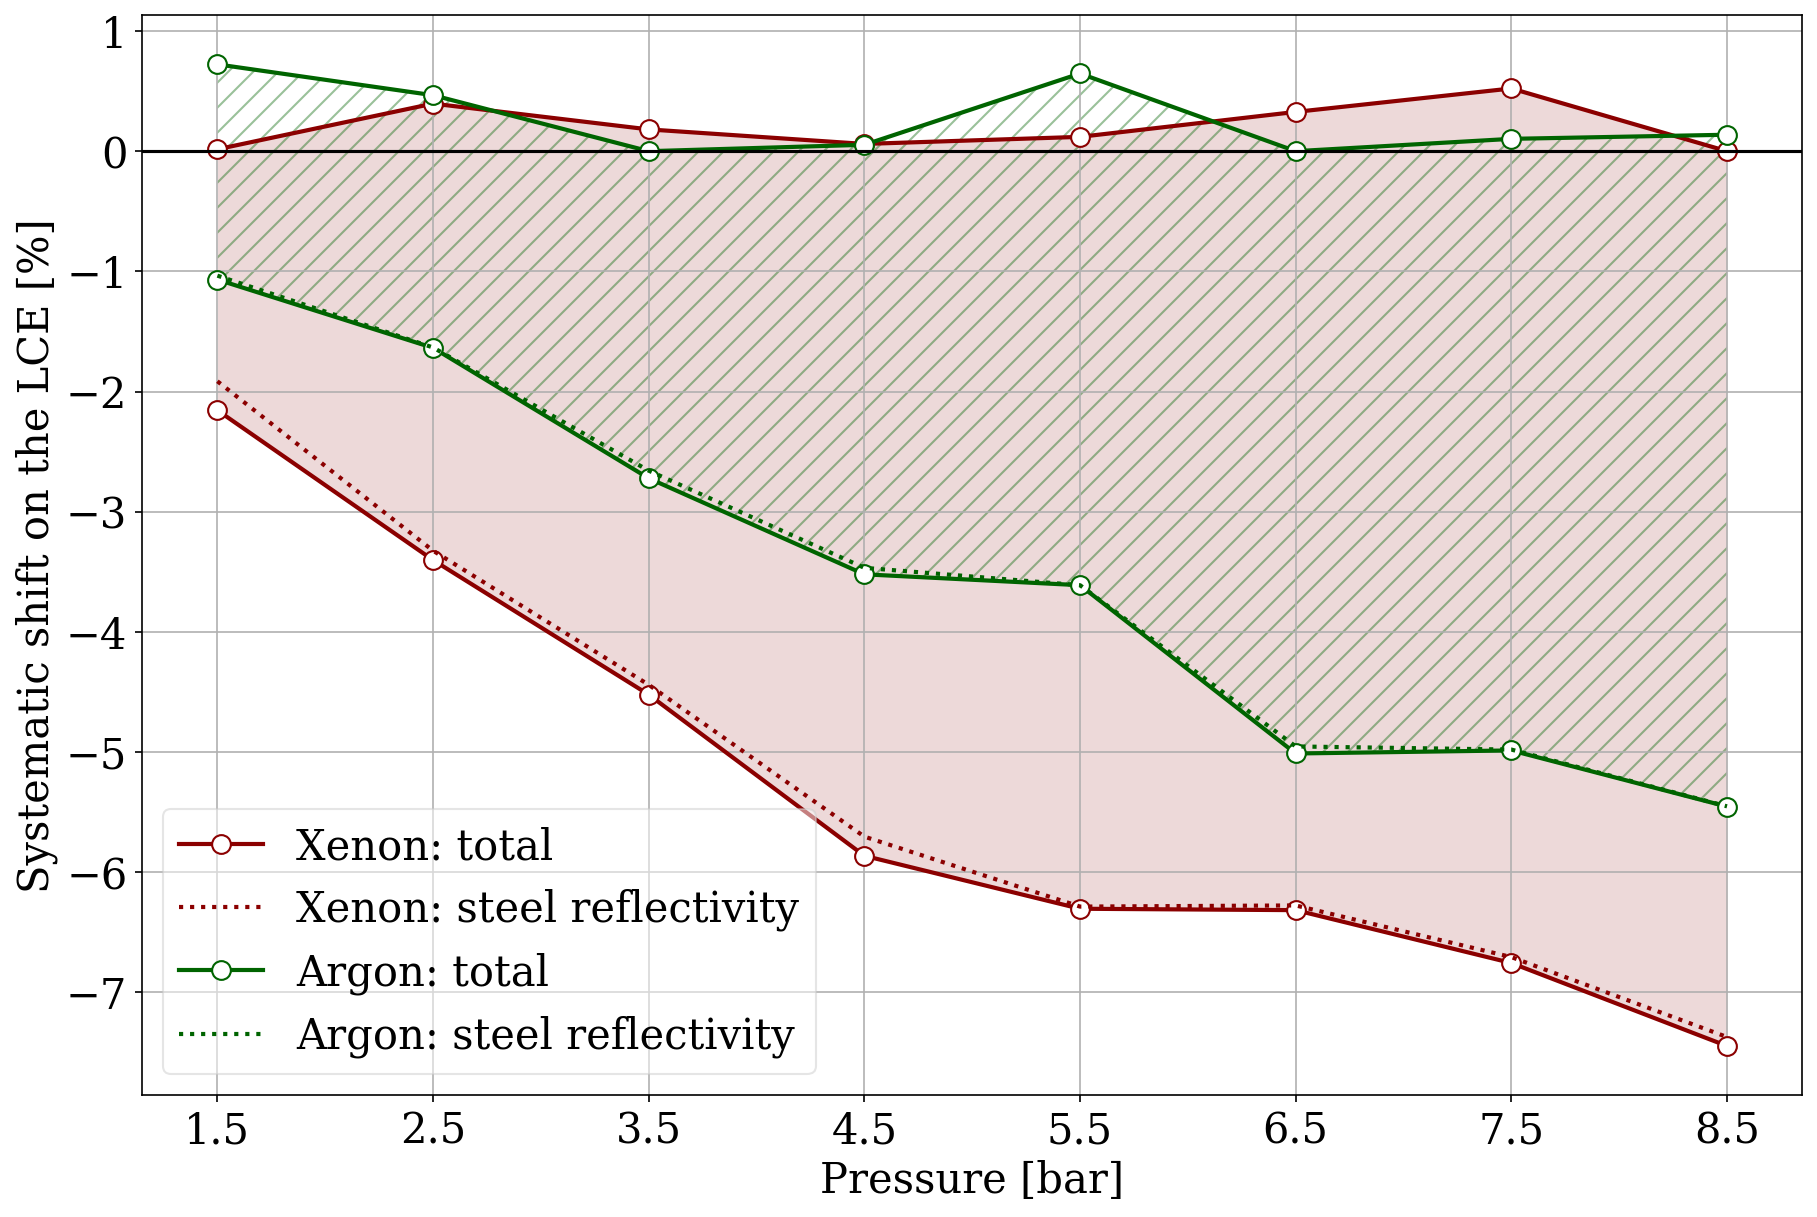

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8), dpi=150, constrained_layout=True)

for gas in ('Xe', 'Ar'):
    d = syst_vs_p.loc[gas]
    # xenon band filled, argon band hatched, so they stay readable where they overlap
    if gas == 'Xe':
        ax.fill_between(d.index, d['total_down'], d['total_up'], color=GAS_COLORS[gas], alpha=0.15, lw=0)
    else:
        ax.fill_between(d.index, d['total_down'], d['total_up'], facecolor='none', edgecolor=GAS_COLORS[gas],
                        hatch='//', alpha=0.4, lw=0)
    ax.plot(d.index, d['total_up'],   '-o', color=GAS_COLORS[gas], markerfacecolor='white', markersize=9, lw=2,
            label=f'{GAS_NAMES[gas]}: total')
    ax.plot(d.index, d['total_down'], '-o', color=GAS_COLORS[gas], markerfacecolor='white', markersize=9, lw=2)
    ax.plot(d.index, d['Steel reflectivity_down'], ':', color=GAS_COLORS[gas], lw=2,
            label=f'{GAS_NAMES[gas]}: steel reflectivity')

ax.axhline(0, color='k', lw=1.5)
ax.set_xlabel('Pressure [bar]')
ax.set_ylabel(r'Systematic shift on the LCE [%]')
ax.set_xticks(all_pressures, [f'{p:g}' for p in all_pressures])
ax.grid(True)
ax.legend(loc='lower left', framealpha=0.5, fontsize=font_size)
plt.show()

## What the results say

At 8.5 bar the result reproduces the reference figure: steel reflectivity about $-7.4\%$ (Xe) and $-5.5\%$ (Ar),
UNIFIED model $-0.6\%$ (Xe) and $+0.1\%$ (Ar), and the PTFE reflectivity and polishing below 1%.

* **Steel reflectivity dominates.** It changes almost only the source absorption ($\varepsilon_{\rm source}$), not the teflon one:
  the source holder is metal, so how much light it reflects decides how much is lost there. It gives a negative
  shift of several % on the LCE, and it grows with pressure because the light is produced closer to the source
  when the alpha tracks are shorter (see `GeometricCorrections.ipynb`).
* **The PTFE variations (reflectivity, polishing, UNIFIED model) are small**: below 1% in xenon and a few 0.1% in
  argon, only a few times the MC statistics (the grey `base20k` row). Part of each bar is therefore statistical
  noise, which makes them a conservative estimate.
  Note that even 60% PTFE reflectivity barely changes the fraction of photons counted as `teflon_hits`. This
  should be checked with whoever made the simulation: if `teflon_hits` counts the photons that **reach** the teflon
  rather than the ones **absorbed** there, the teflon reflectivity would not show up in $\varepsilon_{\rm tot}$ by construction.
* **Not included** here: the FE (front-end) and MPPC calibration systematics of the reference figure. They come from
  the measurement, not from the optical simulation, and have to be added in quadrature to the total.